In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")
print("Files loaded successfully!")

Files loaded successfully!


In [3]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nTraining target counts:")
print(y_train.value_counts())
print("\nTesting target counts:")
print(y_test.value_counts())

X_train shape: (800, 79)
X_test shape: (200, 79)
y_train shape: (800,)
y_test shape: (200,)

Training target counts:
incident_target
0    722
1     78
Name: count, dtype: int64

Testing target counts:
incident_target
0    180
1     20
Name: count, dtype: int64


In [4]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
print("Random Forest model created!")

Random Forest model created!


In [5]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [6]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]
print("Predictions created successfully!")

Predictions created successfully!


In [7]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 91.5 %


In [8]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1-score:", round(f1 * 100, 2), "%")
print("ROC-AUC:", round(roc_auc * 100, 2), "%")

Precision: 63.64 %
Recall: 35.0 %
F1-score: 45.16 %
ROC-AUC: 86.86 %


In [9]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Incident", "Incident"],
    zero_division=0
))

              precision    recall  f1-score   support

 No Incident       0.93      0.98      0.95       180
    Incident       0.64      0.35      0.45        20

    accuracy                           0.92       200
   macro avg       0.78      0.66      0.70       200
weighted avg       0.90      0.92      0.90       200



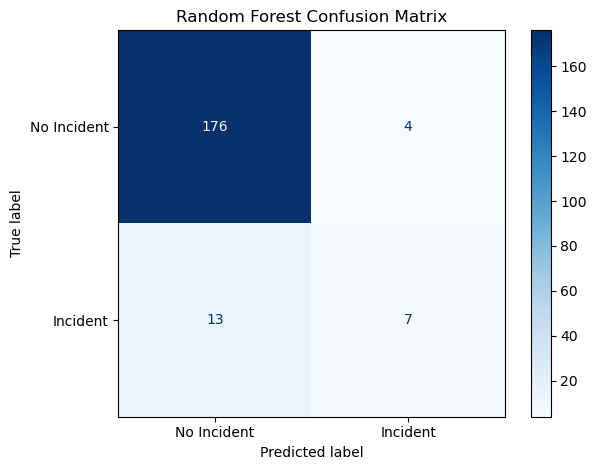

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Incident", "Incident"],
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


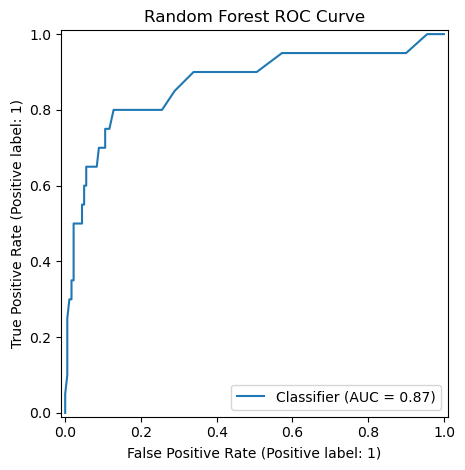

In [11]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)
plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.show()

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print(feature_importance.head(10))

                     Feature  Importance
11             anomaly_score    0.105198
0              cpu_usage_pct    0.079264
4           response_time_ms    0.075424
5                error_count    0.074834
15    average_resource_usage    0.073474
8              temperature_c    0.067487
3         network_latency_ms    0.059202
1           memory_usage_pct    0.059108
7            packet_loss_pct    0.050452
16  error_rate_per_100_users    0.043828


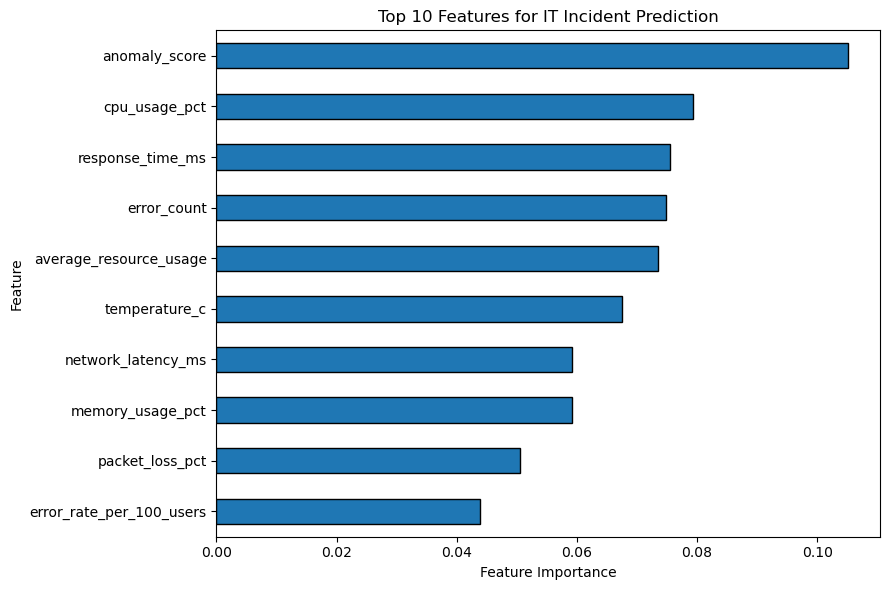

In [14]:
top_features = feature_importance.head(10).sort_values(
    by="Importance"
)
top_features.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(9, 6),
    legend=False,
    edgecolor="black"
)
plt.title("Top 10 Features for IT Incident Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [15]:
joblib.dump(
    model,
    "random_forest_it_incident_model.pkl"
)
print("Model saved successfully!")

Model saved successfully!


In [16]:
results = X_test.copy()
results["Actual"] = y_test.reset_index(drop=True)
results["Predicted"] = y_pred
results["Incident_Probability"] = y_probability
results.to_csv(
    "Random_Forest_Predictions.csv",
    index=False
)
print("Prediction results saved successfully!")

Prediction results saved successfully!


In [17]:
print("=" * 55)
print("PHASE 4 - RANDOM FOREST SUMMARY")
print("=" * 55)
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1-score:", round(f1 * 100, 2), "%")
print("ROC-AUC:", round(roc_auc * 100, 2), "%")
print("=" * 55)
print("Phase 4 completed successfully!")

PHASE 4 - RANDOM FOREST SUMMARY
Training records: 800
Testing records: 200
Accuracy: 91.5 %
Precision: 63.64 %
Recall: 35.0 %
F1-score: 45.16 %
ROC-AUC: 86.86 %
Phase 4 completed successfully!
